# Understanding Your Data (Pandas Only) - Titanic Dataset

```text
1. Understanding Your Data
   │
   ├── Asking Basic Questions (7)
   │
   ├── 1 How big is the data?
   │      → df.shape - (rows, cols)
   │      → number of rows - len(df)
   │
   ├── 2 How does the data look?
   │      → df.head()
   │      → df.tail()
   │      → df.sample(5)
   │
   ├── 3 What are the data types of columns?
   │      → df.dtypes
   │      → df.info()
   │
   ├── 4 Are there any missing values?
   │      → any there any columns with missing/null values? - df.isnull().any()
   │      → missing-value counts? - df.isnull().sum()
   |      → Remove missing value rows? - df=df.dropna() / df.dropna(["col1","col3"],axis=1,inplace=True)
   │
   ├── 5 How does the data look mathematically?
   │      → df.describe() - numeric columns/data only
   │      → df['Age'].mean()
   │      → df['Age'].std()
   │      → df['Age'].min()
   │      → df['Age'].max()
   |      → df['Age'].quantile(0.25) → Q1
   |      → df['Age'].quantile(0.50) → Q2 / Median
   |      → df['Age'].quantile(0.75) → Q3
   │
   ├── 6 Are there any duplicate values?
   │      → df.duplicated()
   │      → dg.duplicated().sum()
   |      → drop duplicate rows - df=df.drop_duplicates() / df.drop_duplicates(inplace=True)
   │
   └── 7 What is the correlation between the columns?
          → df.corr(numeric_only=True) - numeric columns/data only
          → correlation matrix
          → heatmap

**df - mostly returns data frame**
```


In [ ]:
# import and load the dataset
import pandas as pd

In [39]:
df = pd.read_csv("train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


## 1. How big is the data?

In [ ]:
# rows, cols
df.shape

(891, 12)

In [ ]:
# rows
len(df)

891

## 2. How does the data look?

In [ ]:
# returns top 5 rows - data frame
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# returns random rows - data frame
df.sample()
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
142,143,1,3,"Hakkarainen, Mrs. Pekka Pietari (Elin Matilda ...",female,24.0,1,0,STON/O2. 3101279,15.8500,NaN,S
22,23,1,3,"McGowan, Miss. Anna ""Annie""",female,15.0,0,0,330923,8.0292,NaN,Q
505,506,0,1,"Penasco y Castellana, Mr. Victor de Satode",male,18.0,1,0,PC 17758,108.9000,C65,C
222,223,0,3,"Green, Mr. George Henry",male,51.0,0,0,21440,8.0500,NaN,S
190,191,1,2,"Pinsky, Mrs. (Rosa)",female,32.0,0,0,234604,13.0000,NaN,S


In [ ]:
# return bottom 5 rows - dataframe
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [27]:
df.columns
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

## 3. What are the data types of columns?

In [13]:
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [ ]:
# Gives a summary of the DataFrame, including columns, data types, non-null values, and memory usage.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


## 4. Are there any missing values?

In [15]:
df.isna()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [16]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().any()

PassengerId    False
Survived       False
Pclass         False
Name           False
Sex            False
Age             True
SibSp          False
Parch          False
Ticket         False
Fare           False
Cabin           True
Embarked        True
dtype: bool

In [ ]:
# any of the below gives number of null values count
df.isna().sum()
# most used
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [ ]:
# value_counts() → counts the frequency of each unique value, commonly used for categorical columns
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

##### Dropping Columns Quick Notes

1. **Drop columns / rows** - Remove unwanted columns

   * `df.drop(...)` → Removes specified rows or columns.
   * `axis=1` → columns | `axis=0` → rows
   * `data.drop('col1', axis=1)` → Removes a **single column**.
   * `data.drop(['col1', 'col2'], axis=1)` → Removes **multiple columns**.

2. **Missing values**

   * `df.dropna()` → Removes rows containing **missing (`NaN`) values**.

3. **Duplicate rows**

   * `df.drop_duplicates()` → Removes **duplicate rows**.

4. **Returned DataFrame & `inplace`**

   * `df.drop(...)`, `df.dropna()`, `df.drop_duplicates()` → By default, **return a new DataFrame**; the original DataFrame is unchanged.
   * Assign back to save the change: `df = df.dropna()` or use 
   * `inplace=True` → Modifies the **original DataFrame directly**.
   * Examples: `df.dropna(inplace=True)`, `df.drop_duplicates(inplace=True)`, `df.drop('col1', axis=1, inplace=True)`

   **Pandas `inplace=True`**

   Simple rule:

   If the Pandas method **supports** **`inplace=True`**, then:

   ```python
   df.method(inplace=True)
   ```

   modifies the original `df`.

   But **don't assume every Pandas method supports it**.

5. **Check remaining data**

   * `len(df)` → Returns the **number of rows** remaining in the DataFrame.


In [35]:
df.drop("Embarked", axis=1, inplace=True)
df.shape

(891, 11)

In [38]:
df.dropna()
df.shape
#  By default, **return a new DataFrame**; the original DataFrame is unchanged. Assign to dataframe or use inplace=True
df = df.dropna()
df.shape

(185, 11)

## 5. How does the data look mathematically?

In [ ]:
# reverting back dropped columns for proper analyzation
df = pd.read_csv("train.csv")
# describe() - applies on numeric data only
# df.describe() gives a quick statistical summary of the numerical columns in a DataFrame.
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


##### What to look for in describe()

- `count` → Compare with total rows to identify missing values and how many need to be handled before analysis/modeling
   - count = total rows → No missing values in that column.
   - count < total rows → Missing values are present.
   - Larger difference → More missing values need to be handled before analysis/modeling.
- `Mean` → average value around which the data is centered.  it is calculated using every value and can be affected by extreme values
   - Gives a general idea of where the data is centered.
   - Compare mean with 50% (median) to get a quick hint about possible skewness.
   - **Mean can be pulled toward extreme values.**
- `mean vs 50% (median)` → Compare them to get a quick hint about **possible skewness**. Large difference may indicate skewness

    **Mean**
    - `Mean` → The **arithmetic average** of all values; it represents the average/center of the data.
    - Mean is **sensitive to extreme values** because every value contributes to the calculation.

    **Median**
    - `Median` → The **middle value** when the data is arranged in ascending order.
    - Median is **less affected by extreme values** compared with the mean.

    **Mode**
    - `Mode` → The **most frequently occurring value** in the data.
    - Mode represents the value around which the data has the **highest frequency**.

    **Using Mean, Median and Mode for Skewness**
    - **Symmetric** → `Mean ≈ Median ≈ Mode`
    - **Right / Positive skew** → `Mode < Median < Mean` → long tail toward the **right**; high values pull the mean upward.
    - **Left / Negative skew** → `Mean < Median < Mode` → long tail toward the **left**; low values pull the mean downward.
    - `Mean > Median` → Possible **right/positive skew** → **extreme high values pull the mean toward the right (upward)**. Since only a **small number of observations have very high values**, these values extend farther toward the right, creating a **long right tail →**, hence the name **right/positive skew**.
    - `Mean < Median` → Possible **left/negative skew** → **extreme low values pull the mean toward the left (downward)**. Since only a **small number of observations have very low values**, these values extend farther toward the left, creating a **long left tail ←**, hence the name **left/negative skew**.
    - `Mean ≈ Median` → No strong skew indicated → Values are distributed more **symmetrically** around the center, so there is no long tail clearly extending toward either side.

    **Histogram - Data Distribution - Skewness** :
    - A **histogram** is used to understand how the values of **one numerical column are distributed**.It does this by:
       - Steps :
          ```text
          1. Taking all the values in the column.
          2. Dividing the value range into **bins** (intervals/ranges).
          3. Counting how many observations fall into each bin.
          4. Representing those counts using bars.
          ```
       - Therefore:
         - **X-axis** → Fare ranges (**bins**)
         - **Y-axis** → Number of observations (**count/frequency**)
         - **Bar height** → How many observations are in that range
       - For example,    `df["Fare"].hist()`
         - Suppose the data is:Fare values → 10, 20, 25, 30, 35, 40, 45, 60, 120, 150
         The observations are grouped into bins: `0–50` → **7 observations** ; `50–100` → **1 observation** ;  `100–150` → **1 observation** ; `150–200` → **1 observation**
         - Therefore, the `0–50` bar will be the **tallest**, because most observations fall in that range.
         - <img src="image.png" width="500">

       - The histogram helps us visually identify:
          - Where most values are concentrated
          - How spread out the values are
          - Whether the distribution is **symmetric or skewed**
          - Whether there are unusually extreme values

      - **Example of right skewness:**
          - If most passengers have Fare values between **0–50**, but only a few passengers have very high fares like **300–500**, the bars will be concentrated on the left and a few smaller bars will extend toward the right.
          - These few high values create a **long right tail →**, indicating a **right/positive skewed distribution**.

      - **Important:** The histogram does not create skewness. It **shows the distribution**, allowing us to visually observe skewness.

    - Histogram reasoning for skewness :
      - **Right / Positive skew** → Many observations are concentrated at **lower-medium values**, while a **small number of very high values** extend farther toward the right.
         - Histogram → More/taller bars toward the lower values + fewer/shorter bars continuing toward higher values.
         - These few high values create the **long right tail →**.
         - The high values pull the **mean toward the right/upward**.
         - Therefore → `Mean > Median` → **Right / Positive skew**.

      - **Left / Negative skew** → Many observations are concentrated at **higher values**, while a **small number of very low values** extend farther toward the left.
         - Histogram → More/taller bars toward the higher values + fewer/shorter bars continuing toward lower values.
         - These few low values create the **long left tail ←**.
         - The low values pull the **mean toward the left/downward**.
         - Therefore → `Mean < Median` → **Left / Negative skew**.

    - The side where the few extreme values stretch out is the side where the tail is — and that is what determines the name of the skew.
       - So few high values → right tail → right/positive skew.
       - Few low values → left tail → left/negative skew.

    - **Skewness ≠ Outliers**
       - **Skewness** → describes the **overall shape/asymmetry** of the distribution.
       - **Outlier** → an **individual value** that is unusually far from the rest.
       - For example, if most fares are ₹10–₹50 but a few fares are ₹300–₹500:
          - Those ₹300–₹500 values may be **outliers**.
          - They extend the distribution toward the **right**, creating a **right-skewed distribution**.
          - They also pull the **mean upward**.
       - So,  **Outliers can cause skewness, but a skewed distribution does not necessarily mean it contains outliers.**

    - **Mean / Median / Skewness for categorical columns** → Generally **not meaningful** for ordinary categorical data.
       - **Types of Data:**
         - **Numerical** → Continuous (e.g., `Age: 24.5`) / Discrete (e.g., `Number of siblings: 2`)
         - **Categorical** → Nominal (no order, e.g., `Gender: Male/Female`) / Ordinal (has order, e.g., `Rating: Poor < Average < Good < Excellent`)
       - Some categorical columns may be represented using numbers, such as `Sex: 0/1` or `Pclass: 1/2/3`.
       - Even though they contain numbers, the numbers may represent **categories rather than continuous numerical values**.
       - Therefore, mean, median and skewness should **not automatically be interpreted like normal numerical data**.
       - For categorical columns, focus more on **value counts, frequency and proportions**.

- `min/max` → Look for extreme or unusual values / possible outliers.
  - `min` → The **smallest observed value** in the column.Very small/unusual values → Possible extreme values or data issues. Compare it with 25% (Q1) to see how far the lower extreme is from the main data.
  - `max` → The **largest observed value** in the column.Very large/unusual values → Possible extreme values or data issues. Compare it with 75% (Q3) to see how far the upper extreme is from the main data
  - `max - min` → Shows the **overall range** of the observed values, but it can be strongly affected by extreme values. - `max - min` → Shows the **range** of the data; a very small range **may indicate** a categorical/discrete column, but it does not necessarily mean the column is categorical.
  - Compare `min/max` with `25%` and `75%` to see whether values are unusually far from the main data.
  - Min/max alone **cannot prove** that a value is an outlier; use methods such as **IQR or box plot** later.
  
- `std` → Understand how spread out the values are around the mean. This number comes from looking at **every value's distance from the mean**.

  - Larger `std` → Values generally have **more variation** around the mean. Values have relatively high variation/spread
  - Smaller `std` → Values are generally **more concentrated** around the mean.
  - Compare std with the mean to understand whether the variation is small or large relative to the average.
  - `std` measures **spread**, not whether values are outliers.

- `25% and 75%` → Understand where the **middle 50% of data lies**.

  - `25% (Q1)` → 25% of the values are **at or below** this value.
  - `50% (Median)` → 50% of the values are **at or below** this value. Less affected by extreme values than the mean.Compare with mean to get a quick hint about possible skewness.
  - `75% (Q3)` → 75% of the values are **at or below** this value.
  - Therefore, `Q1 → Q3` contains the **middle 50% of the data**.
  - Q3 - Q1 → IQR, which measures the spread of the middle 50%.
  - Larger IQR → Middle 50% is more spread out.
  - Smaller IQR → Middle 50% is more concentrated.

- `min → 25% → 50% → 75% → max` → Get a quick idea of **how the values are distributed**.

  - Look at the **spacing between these points**.
  - Similar spacing → Values may be distributed relatively evenly.
  - Unequal spacing → May indicate **skewness, concentration, or extreme values**.
  - This gives a quick distribution overview before using plots such as a **histogram or box plot**.

- Missingness → Center → Skew → Range → Spread → Quartiles → Distribution → Possible outliers

##### Observations - Titanic insights

- `count`
  - `Age` → `714` out of `891` rows → **177 missing values**.
  - All other columns have `891` values → **No missing values** in those columns.
  - `Age` needs to be handled before further analysis/modeling.

- `mean`
  - `Age` → Mean = `29.70` → Average passenger age is around **30 years**.
  - `Fare` → Mean = `32.20` → Average fare paid was around **32.20**.
  - `SibSp` → Mean = `0.52` → On average, passengers had around **0.5 siblings/spouses aboard**.
  - `Parch` → Mean = `0.38` → On average, passengers had around **0.38 parents/children aboard**.
  - `Survived` → Mean = `0.38` → Since `Survived` is binary (`0/1`), around **38.4% of passengers survived**.
  - `Pclass` → Mean = `2.31` → Passengers were distributed across the three classes, with the average class around **2.3**.

- `mean vs median`
  - `Age` → Mean = `29.70`, Median = `28` → Mean is slightly higher → **possible slight right skew**.
  - `Fare` → Mean = `32.20`, Median = `14.45` → Large difference → **strong indication of right/positive skew**.
  - `SibSp` → Mean = `0.52`, Median = `0` → Mean is higher → **possible right skew**.
  - `Parch` → Mean = `0.38`, Median = `0` → Mean is higher → **possible right skew**.
  - `Pclass` → Mean = `2.31`, Median = `3` → Mean is lower than median, but `Pclass` is an **ordinal/categorical-like variable**, so the usual skewness interpretation is not very meaningful here.

- `min/max`
  - `Age` → `0.42 → 80` → Passengers range from **infants to 80 years old**.
  - `Fare` → `0 → 512.33` → Very wide range; the maximum fare is much higher than most fares and should be investigated as a possible **extreme value**.
  - `SibSp` → `0 → 8` → Most passengers had few or no siblings/spouses, while a small number had much higher values.
  - `Parch` → `0 → 6` → Most passengers had no parents/children aboard, while a small number had higher values.
  - `Pclass` → `1 → 3` → Only three passenger classes exist.
  - `Survived` → `0 → 1` → Confirms that this is a **binary variable**.

- `std`
  - `Age` → `std = 14.53` → There is **considerable variation** in passenger ages around the mean of `29.70`.
  - `Fare` → `std = 49.69` → Fare has **high variation** around the mean, which is consistent with the wide range and high maximum fare.
  - `SibSp` → `std = 1.10` → Some variation exists, but most values are relatively close to `0`.
  - `Parch` → `std = 0.81` → Most values are concentrated around `0`, with some passengers having higher values.
  - `Survived` → `std = 0.49` → Expected variation for a binary `0/1` variable; not interpreted like a continuous measurement.

- `25% and 75%`
  - `Age` → `Q1 = 20.13`, `Q3 = 38` → The **middle 50% of passengers are between about 20 and 38 years old**.
  - `Fare` → `Q1 = 7.91`, `Q3 = 31` → The **middle 50% of fares are between 7.91 and 31**.
  - `SibSp` → `Q1 = 0`, `Q3 = 1` → The middle 50% of passengers had **0–1 siblings/spouses** aboard.
  - `Parch` → `Q1 = 0`, `Q3 = 0` → At least **75% of passengers had 0 parents/children** aboard.
  - `Pclass` → `Q1 = 2`, `Q3 = 3` → The middle 50% of passengers were in **2nd or 3rd class**.

- `min → Q1 → median → Q3 → max`
  - `Age` → `0.42 → 20.13 → 28 → 38 → 80`
    - Most ages are concentrated between approximately **20 and 38**.
    - The upper side extends much farther (`38 → 80`) than the lower side (`0.42 → 20.13`).
    - This gives a hint of **right skew**, although the mean/median difference is small.

  - `Fare` → `0 → 7.91 → 14.45 → 31 → 512.33`
    - Most fares are relatively low.
    - The upper side (`31 → 512.33`) is extremely spread out compared with the lower side.
    - Strong indication of a **right-skewed distribution** with possible extreme high fares.

  - `SibSp` → `0 → 0 → 0 → 1 → 8`
    - At least **50% of passengers had 0 siblings/spouses**.
    - At least **75% had 0 or 1**.
    - A small number of passengers had much higher values, producing a **right-skewed distribution**.

  - `Parch` → `0 → 0 → 0 → 0 → 6`
    - At least **75% of passengers had 0 parents/children** aboard.
    - Only a smaller number had values above `0`.
    - This indicates a highly **concentrated distribution around 0**.

- `IQR`
  - `Age` → `38 - 20.13 = 17.87` → The middle 50% of ages span about **17.87 years**.
  - `Fare` → `31 - 7.91 = 23.09` → The middle 50% of fares span about **23.09**.
  - `SibSp` → `1 - 0 = 1` → The middle 50% are concentrated within **0–1**.
  - `Parch` → `0 - 0 = 0` → The middle 50% are all concentrated at **0**.

##### Conclusions :

- `Age` → Has **177 missing values**, average age around **30**, and relatively moderate variation.
- `Fare` → Shows the clearest **right-skewed distribution**, with a mean much higher than the median and a very high maximum value.
- `SibSp` → Most passengers had **0–1 siblings/spouses**, with a few higher values.
- `Parch` → Most passengers had **0 parents/children**, making the data highly concentrated around `0`.
- `Survived` → Binary variable; approximately **38.4% survived**.
- `Pclass` → Contains only **three ordered classes (1, 2, 3)** and should not be interpreted like a continuous numerical variable.
- Overall → `Age` has **missing values**, while `Fare`, `SibSp`, and `Parch` show signs of **right-skewed distributions** and possible extreme values that should be investigated further using plots.

In [45]:
df['Age'].mean()

np.float64(29.69911764705882)

In [46]:
df.Age.median()

np.float64(28.0)

In [50]:
df['Age'].min()
df['Age'].quantile(0.25)

np.float64(20.125)

## 6. Are there any duplicate values?

In [41]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [42]:
df.duplicated().sum()

np.int64(0)

In [43]:
df = df.drop_duplicates()
len(df)

891

## 7. What is the correlation between the columns?

##### Correlation (`corr(numeric_only=True)`)

- `corr()` calculates the correlation between **numerical columns only**.
- It ignores non-numeric columns and calculates correlation only among the numeric columns.
- `df.corr()` → does not work.`df.corr(numeric_only=True)` works
> **Correlation coefficient (Pearson coefficient):** A number between **-1 and +1** that measures the **strength and direction of a linear relationship** between two numerical variables.
> **Correlation Matrix:** A table showing the **Pearson correlation coefficient** between every pair of numerical columns.

|              | Age  | Salary | Experience |
|--------------|------|--------|------------|
| **Age**      | 1.00 | 0.99   | 1.00       |
| **Salary**   | 0.99 | 1.00   | 0.98       |
| **Experience** | 1.00 | 0.98   | 1.00       |


```text
-1                 0                 +1
│------------------│------------------│
strong negative    no linear          strong positive
                   relationship

Correlation: pearson co-eficient
- +1 → perfect positive linear relationship (directly propositional)
-  0 → no linear relationship (no relationship / less dependency)
- -1 → perfect negative linear relationship (inversely propositional)
- How columns are related with each other. How does one column affect other column linearly

- Strong positive correlation → +1

Y
↑
|                    ●
|                ●
|            ●
|        ●
|    ●
| ●
+--------------------------→ X

- As X increases, Y also increases
- Hours studied ↑  →  Marks ↑
- upward straight-line pattern
- Correlation is positive and strong → close to +1.


- Strong negative correlation → -1

Y
↑
| ●
|     ●
|         ●
|             ●
|                 ●
|                     ●
+--------------------------→ X

- As X increases, Y decreases
- Car age ↑  →  Car price ↓
- downward straight-line pattern
- Correlation is negative and strong → close to -1


- No linear correlation → 0

Y
↑
|       ●          ●
|  ●             ●
|          ●
|     ●               ●
|               ●
| ●       ●
+--------------------------→ X

- As X increases, Y doesn't consistently increase or decrease.
- Hours studied → Shoe size
- no clear straight-line pattern
- Correlation is close to 0 → little/no linear relationship
- Correlation matrix → A table showing the correlation coefficient between every pair of numerical columns.
- Can use heatmap to represent correlation matrix
- Feature Selection : A feature with low/zero correlation with the target can be considered as a candidate for removal, but correlation alone should not be used as the final decision because correlation measures only linear relationships. The feature may still have a non-linear relationship with the target and therefore could still be useful for prediction.
- If two features have very similar or identical correlation with the target and are also highly correlated with each other, they may be carrying almost the same information. In such cases, keeping one feature may be sufficient. For example, temp and atemp may contain highly similar information, so we can consider retaining one instead of both to reduce redundancy.
- https://www.youtube.com/watch?v=1fFVt4tQjRE
```


In [ ]:
df.corr(numeric_only=True)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


##### Heatmap

A **heatmap is a data visualization that represents values in a matrix or grid using colors**, where different colors or color intensities make patterns, high/low values, or relationships easier to identify.

A heatmap does **not calculate the values**; it only **visualizes values that are already present in a matrix**.

- Categorical data → `crosstab()` → Count matrix → `heatmap()` → Visualize counts
- Numerical data → `corr()` → Correlation matrix → `heatmap()` → Visualize correlations

For example:
- `crosstab()` → creates a count/frequency matrix → heatmap visualizes it
- `corr()` → creates a correlation matrix → heatmap visualizes it

<Axes: >

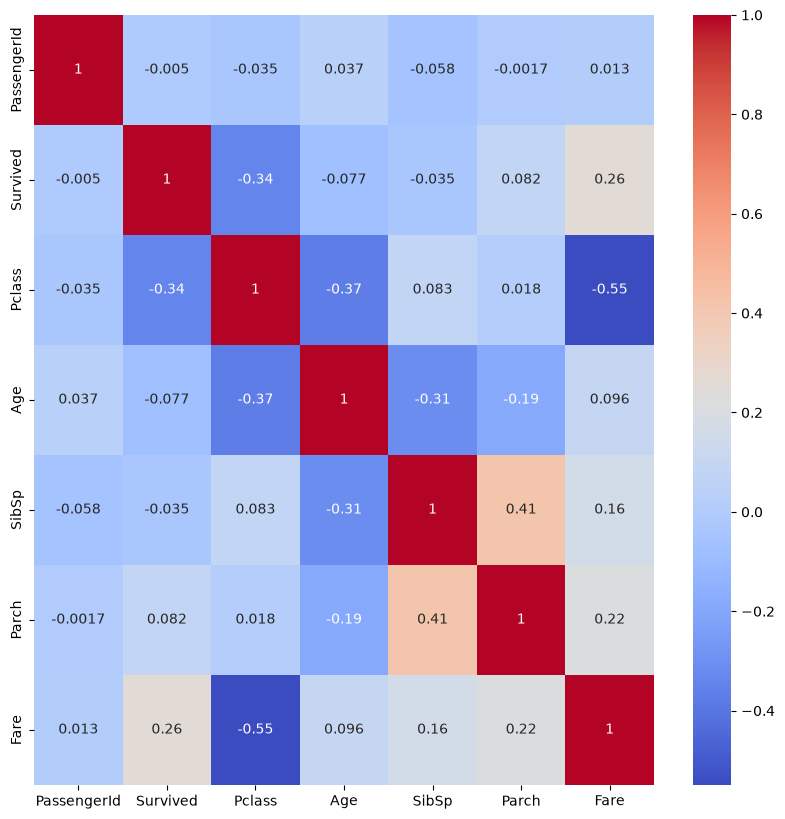

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [52]:
# Target Variable - Survived / Not Survived - Output Column - y
df.corr(numeric_only=True)['Survived']

PassengerId   -0.005007
Survived       1.000000
Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
Parch          0.081629
Fare           0.257307
Name: Survived, dtype: float64

##### Insights Derived
- Fare ↑ and Survival ↑  → If one tends to increase when the other increases → positive correlation
- Pclass ↑ and Survival ↓ → If one tends to increase when the other decreases → negative correlation
- PassengerId and Survival → PassengerId is just an identifier, so its correlation with survival isn't meaningful for modeling
- Same Column - Survival correlation with Survival - strong - 1 